#MODE

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\neeraj\train.csv")
df.shape

(1460, 81)

In [3]:
pd.set_option("display.max_columns",None)
pd.set_option("display.max_rows",None)

In [4]:
cat_vars = df.select_dtypes(include=['object'])

In [5]:
null_var = cat_vars.isnull().mean()*100

In [6]:
drp_col = null_var[null_var>60].keys()

In [7]:
drp_col

Index(['Alley', 'PoolQC', 'Fence', 'MiscFeature'], dtype='object')

In [8]:
drpped = cat_vars.drop(columns=drp_col)
drpped.shape

(1460, 39)

In [14]:
null_per = drpped.isnull().mean()*100
miss2 = null_per[null_per>0].keys()
miss2

Index(['MasVnrType', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
       'BsmtFinType2', 'Electrical', 'FireplaceQu', 'GarageType',
       'GarageFinish', 'GarageQual', 'GarageCond'],
      dtype='object')

In [15]:
drpped['MasVnrType'].mode()[0]

'BrkFace'

In [16]:
drpped['MasVnrType'].value_counts()

MasVnrType
BrkFace    445
Stone      128
BrkCmn      15
Name: count, dtype: int64

In [17]:
for i in miss2:
    drpped[i].fillna(drpped[i].mode()[0], inplace=True)
    print(i, '=', drpped[i].mode()[0] )

    

MasVnrType = BrkFace
BsmtQual = TA
BsmtCond = TA
BsmtExposure = No
BsmtFinType1 = Unf
BsmtFinType2 = Unf
Electrical = SBrkr
FireplaceQu = Gd
GarageType = Attchd
GarageFinish = Unf
GarageQual = TA
GarageCond = TA


C:\Users\neeraj.ck.kumar\AppData\Local\Temp\ipykernel_34516\1230087181.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  drpped[i].fillna(drpped[i].mode()[0], inplace=True)


In [18]:
drpped.isnull().sum()

MSZoning         0
Street           0
LotShape         0
LandContour      0
Utilities        0
LotConfig        0
LandSlope        0
Neighborhood     0
Condition1       0
Condition2       0
BldgType         0
HouseStyle       0
RoofStyle        0
RoofMatl         0
Exterior1st      0
Exterior2nd      0
MasVnrType       0
ExterQual        0
ExterCond        0
Foundation       0
BsmtQual         0
BsmtCond         0
BsmtExposure     0
BsmtFinType1     0
BsmtFinType2     0
Heating          0
HeatingQC        0
CentralAir       0
Electrical       0
KitchenQual      0
Functional       0
FireplaceQu      0
GarageType       0
GarageFinish     0
GarageQual       0
GarageCond       0
PavedDrive       0
SaleType         0
SaleCondition    0
dtype: int64

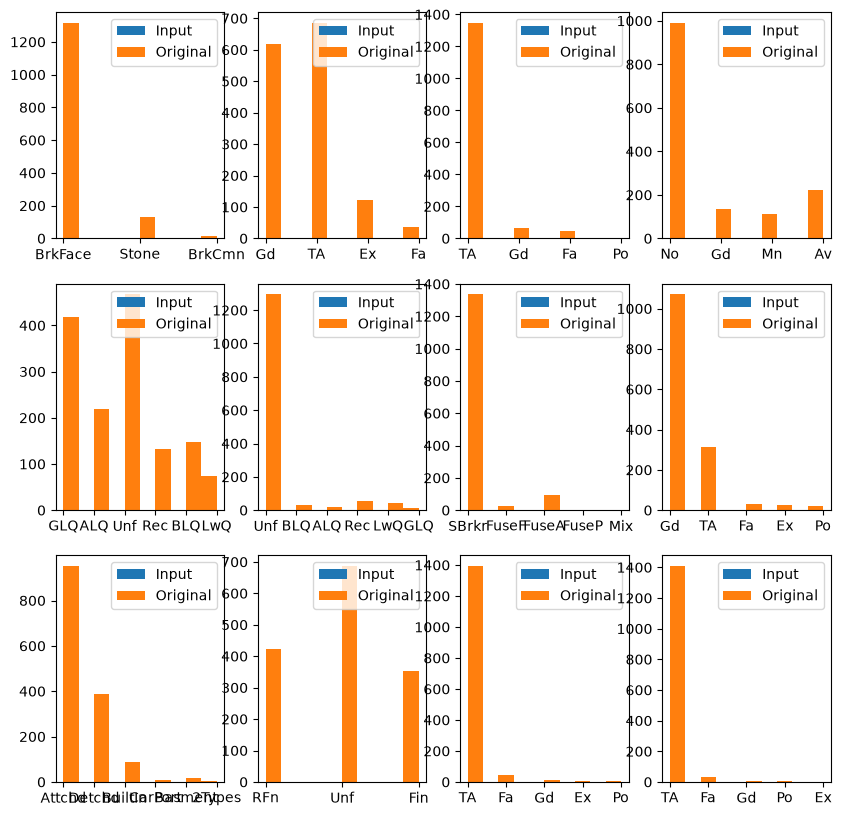

In [21]:
plt.figure(figsize=(10,10))
for i,var in enumerate(miss2):
    plt.subplot(3,4,i+1)
    plt.hist(drpped[var],label='Input')
    plt.hist(cat_vars[var],label='Original')
    plt.legend()